<a href="https://colab.research.google.com/github/Idhil686/roadsense-ml/blob/main/accident_severity_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



## 1. Problem Definition

When a traffic accident is reported, first responders and traffic control centers only have
basic information at first - the weather, the time, and the type of road feature nearby like junction,crossing ,traffic signal
. If we can predict how severe an accident is likely to
be from this basic information, it could help responders prioritize which accidents need
attention first, and help city planners spot conditions that lead to worse accidents.

This is a classification problem: given weather and road conditions, predict the
severity of an accident (1 = minor, 4 = severe).

## 2. Dataset
 used the US Accidents  dataset by Sobhan Moosavi (Kaggle: `sobhanmoosavi/us-accidents`),
which contains millions of real accident records across the US with weather and road data
 instead we worked with a sample of **40,000** rows so the notebook stays quick to run.


In [ ]:
# Data handling and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from imblearn.over_sampling import SMOTE
import joblib


## 3. Data Acquisition
i used the Kaggle API to pull the dataset directly into Colab's environment, rather than
manually downloading and uploading the file. which  avoids having to transfer a multi-gigabyte file
which is much faster and more reliable for a dataset this size.


In [ ]:
!pip install kaggle -q


In [ ]:
!mkdir -p ~/.kaggle
!echo KGAT_25dc4e2e5ac58ef55cd2bee46c37c8a1 > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

!kaggle datasets download -d sobhanmoosavi/us-accidents
!unzip -q us-accidents.zip
!ls *.csv


Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:09<00:00, 75.9MB/s]

US_Accidents_March23.csv


In [ ]:
!pip install imbalanced-learn -q

In [ ]:
# The full file has millions of rows, so we only read the columns we need
# and take a sample of 40,000 rows to keep things quick to run.
use_cols = [
    'Severity', 'Start_Time', 'Temperature(F)', 'Humidity(%)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)',
    'Weather_Condition', 'Sunrise_Sunset', 'Junction', 'Crossing',
    'Traffic_Signal'
]

df = pd.read_csv('US_Accidents_March23.csv', usecols=use_cols)
df = df.sample(n=40000, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()


(40000, 12)


,Severity,Start_Time,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in),Weather_Condition,Crossing,Junction,Traffic_Signal,Sunrise_Sunset
0,1,2020-04-17 09:29:30,78.0,81.0,10.0,13.0,0.01,Mostly Cloudy,False,False,True,Day
1,2,2022-04-21 10:01:00.000000000,55.0,88.0,10.0,9.0,0.00,Mostly Cloudy,True,False,False,Day
2,3,2016-08-12 16:45:00,91.0,47.0,10.0,10.4,NaN,Partly Cloudy,True,False,False,Day
3,3,2019-09-20 15:22:16,67.0,84.0,10.0,3.0,0.00,Cloudy,False,False,False,Day
4,2,2019-06-03 16:55:43,95.0,16.0,10.0,6.0,0.00,Fair,False,False,False,Day


## 4. Data Exploration


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Severity           40000 non-null  int64  
 1   Start_Time         40000 non-null  object 
 2   Temperature(F)     39146 non-null  float64
 3   Humidity(%)        39095 non-null  float64
 4   Visibility(mi)     39097 non-null  float64
 5   Wind_Speed(mph)    36936 non-null  float64
 6   Precipitation(in)  28473 non-null  float64
 7   Weather_Condition  39115 non-null  object 
 8   Crossing           40000 non-null  bool   
 9   Junction           40000 non-null  bool   
 10  Traffic_Signal     40000 non-null  bool   
 11  Sunrise_Sunset     39862 non-null  object 
dtypes: bool(3), float64(5), int64(1), object(3)
memory usage: 2.9+ MB


In [ ]:
df.isnull().sum()


,0
Severity,0
Start_Time,0
Temperature(F),854
Humidity(%),905
Visibility(mi),903
Wind_Speed(mph),3064
Precipitation(in),11527
Weather_Condition,885
Crossing,0
Junction,0


In [ ]:
df.describe()


,Severity,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,40000.000000,39146.000000,39095.000000,39097.000000,36936.000000,28473.000000
mean,2.211950,61.511641,64.828904,9.090404,7.682080,0.007648
std,0.485008,19.106671,22.805237,2.718030,6.754789,0.093702
min,1.000000,-35.000000,3.000000,0.000000,0.000000,0.000000
25%,2.000000,49.000000,48.000000,10.000000,4.600000,0.000000
50%,2.000000,64.000000,67.000000,10.000000,7.000000,0.000000
75%,2.000000,76.000000,84.000000,10.000000,10.400000,0.000000
max,4.000000,115.000000,100.000000,80.000000,822.800000,10.000000


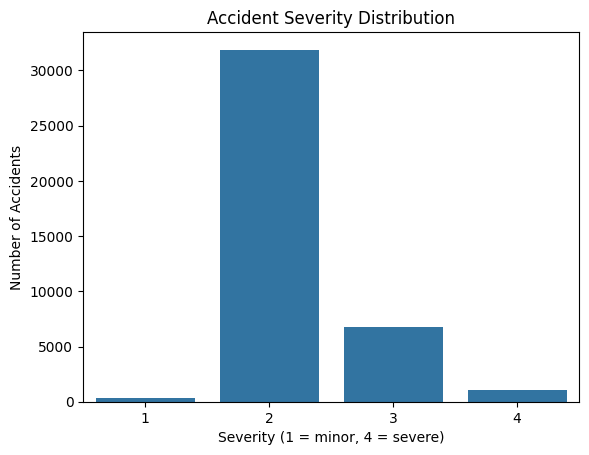

In [ ]:
# How many accidents fall into each severity level?
sns.countplot(x='Severity', data=df)
plt.title('Accident Severity Distribution')
plt.xlabel('Severity (1 = minor, 4 = severe)')
plt.ylabel('Number of Accidents')
plt.show()


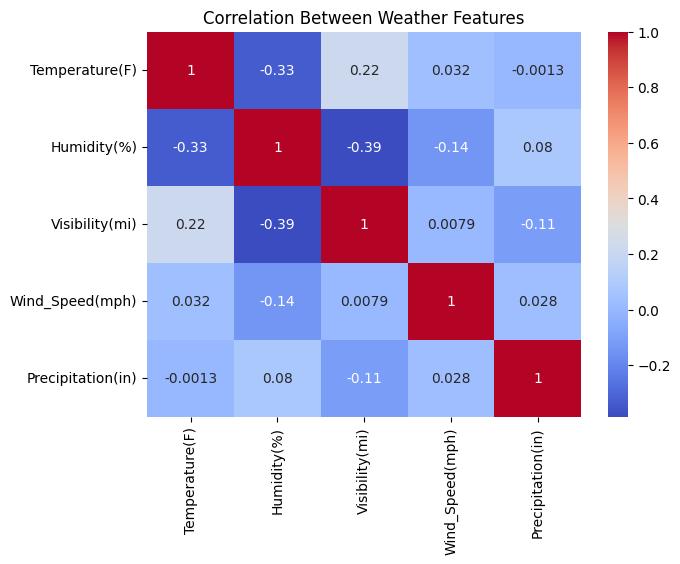

In [ ]:
# Correlation between the numeric weather features
numeric_cols = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)',
                'Wind_Speed(mph)', 'Precipitation(in)']

plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Weather Features')
plt.show()


## 5. Data Cleaning

We clean up missing values, pull the hour and day of the week out of the timestamp, and
encode the categorical columns so the model can use them.


In [ ]:
df = df.dropna(subset=['Severity'])

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df['Weather_Condition'] = df['Weather_Condition'].fillna('Clear')
df['Sunrise_Sunset'] = df['Sunrise_Sunset'].fillna('Day')

df.isnull().sum().sum()


np.int64(0)

In [ ]:
# Pull hour of day and day of week out of Start_Time
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed', errors='coerce')
df = df.dropna(subset=['Start_Time'])

df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek  # 0 = Monday

df[['Start_Time', 'Hour', 'DayOfWeek']].head()


,Start_Time,Hour,DayOfWeek
0,2020-04-17 09:29:30,9,4
1,2022-04-21 10:01:00,10,3
2,2016-08-12 16:45:00,16,4
3,2019-09-20 15:22:16,15,4
4,2019-06-03 16:55:43,16,0


In [ ]:
# Weather_Condition has too many unique text values, so we keep only the
# 5 most common ones and label everything else as 'Other'
top_weather = df['Weather_Condition'].value_counts().head(5).index
df['Weather_Condition'] = df['Weather_Condition'].where(
    df['Weather_Condition'].isin(top_weather), 'Other'
)

df['Weather_Condition'].value_counts()


,count
Weather_Condition,
Fair,13176
Other,8532
Mostly Cloudy,5212
Clear,5162
Cloudy,4183
Partly Cloudy,3735


In [ ]:
# Encode the two categorical columns
weather_encoder = LabelEncoder()
df['Weather_Enc'] = weather_encoder.fit_transform(df['Weather_Condition'])

sunrise_encoder = LabelEncoder()
df['Sunrise_Enc'] = sunrise_encoder.fit_transform(df['Sunrise_Sunset'])

# The road-feature columns are already True/False,  we convertto 0/1
df['Junction'] = df['Junction'].astype(int)
df['Crossing'] = df['Crossing'].astype(int)
df['Traffic_Signal'] = df['Traffic_Signal'].astype(int)

df[['Weather_Condition', 'Weather_Enc', 'Sunrise_Sunset', 'Sunrise_Enc']].head()


,Weather_Condition,Weather_Enc,Sunrise_Sunset,Sunrise_Enc
0,Mostly Cloudy,3,Day,0
1,Mostly Cloudy,3,Day,0
2,Partly Cloudy,5,Day,0
3,Cloudy,1,Day,0
4,Fair,2,Day,0


In [ ]:
feature_columns = [
    'Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)',
    'Precipitation(in)', 'Hour', 'DayOfWeek', 'Weather_Enc', 'Sunrise_Enc',
    'Junction', 'Crossing', 'Traffic_Signal'
]

X = df[feature_columns]
y = df['Severity']

y.value_counts(normalize=True)


,proportion
Severity,
2,0.797025
3,0.168875
4,0.025725
1,0.008375


## 6. Train-Test Split

 used a stratified split so both sets have a similar mix of severity classes.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (32000, 12)
Test shape: (8000, 12)


In [ ]:
# Applied SMOTE to the training data only, to balance out the severity classes
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_resampled.value_counts().to_dict())

Before SMOTE: {2: 25505, 3: 5404, 4: 823, 1: 268}
After SMOTE: {2: 25505, 3: 25505, 4: 25505, 1: 25505}


## 7. Model Training

i  trained  a Random Forest and a Gradient Boosting classifier, and compare them. Since the
severity classes are imbalanced (most accidents are Severity 2), we use
class_weight='balanced' for the Random Forest.

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

print(f"RF Training Accuracy: {rf_model.score(X_train, y_train):.3f}")
print(f"RF Testing Accuracy: {rf_model.score(X_test, y_test):.3f}")


RF Training Accuracy: 0.995
RF Testing Accuracy: 0.793


In [ ]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

print(f"GB Training Accuracy: {gb_model.score(X_train, y_train):.3f}")
print(f"GB Testing Accuracy: {gb_model.score(X_test, y_test):.3f}")


GB Training Accuracy: 0.799
GB Testing Accuracy: 0.796


## 8. Evaluation

looked  at accuracy plus a classification report and confusion matrix for the better-performing
model (Random Forest)


In [ ]:
rf_preds = rf_model.predict(X_test)
print(classification_report(y_test, rf_preds))


              precision    recall  f1-score   support

           1       0.00      0.00      0.00        67
           2       0.80      0.98      0.88      6376
           3       0.42      0.06      0.10      1351
           4       0.00      0.00      0.00       206

    accuracy                           0.79      8000
   macro avg       0.31      0.26      0.25      8000
weighted avg       0.71      0.79      0.72      8000



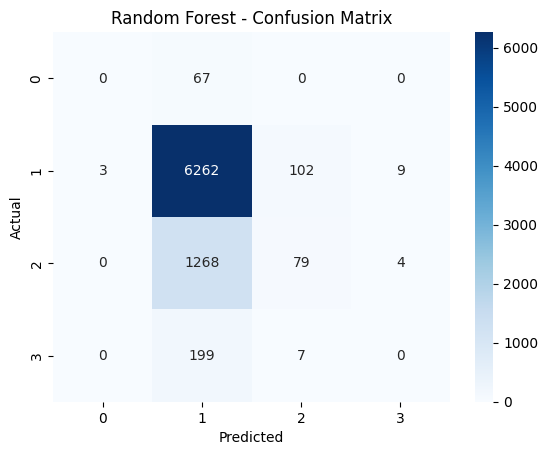

In [ ]:
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()




## 9. Fine-Tuning

Instead of testing values by hand, GridSearchCV is used to automatically try different
combinations of n_estimators, max_depth, and min_samples_split, and picks whichever
combination gives the best macro F1-score.

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',   # optimizing for macro F1, not plain accuracy - directly addresses the imbalance issue
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train_resampled, y_train_resampled)

print("Best parameters:", grid_search.best_params_)
print("Best CV macro F1-score:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV macro F1-score: 0.884842659158186


In [ ]:
final_model = grid_search.best_estimator_
final_preds = final_model.predict(X_test)

print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           1       0.05      0.07      0.06        67
           2       0.83      0.82      0.82      6376
           3       0.29      0.30      0.30      1351
           4       0.01      0.01      0.01       206

    accuracy                           0.71      8000
   macro avg       0.30      0.30      0.30      8000
weighted avg       0.71      0.71      0.71      8000



## 10. Feature Importance


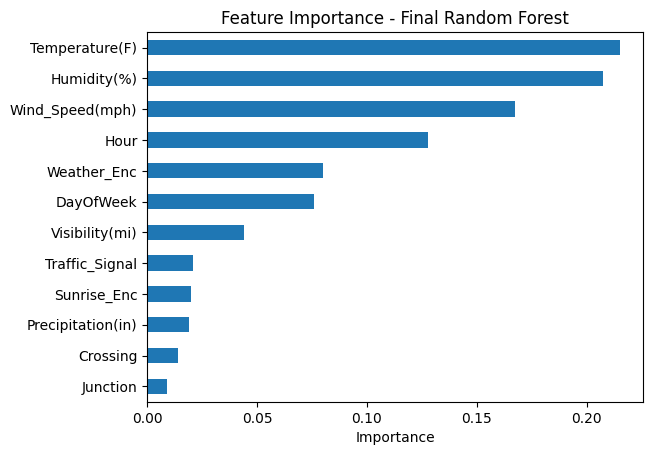

In [ ]:
importances = pd.Series(final_model.feature_importances_, index=feature_columns)
importances = importances.sort_values()

importances.plot(kind='barh')
plt.title('Feature Importance - Final Random Forest')
plt.xlabel('Importance')
plt.show()


## 11. Saving the Model for Deployment

We save the model and encoders so the Flask API can load them and make predictions.


In [ ]:
joblib.dump(final_model, 'accident_severity_model.pkl')
joblib.dump(weather_encoder, 'weather_encoder.pkl')
joblib.dump(sunrise_encoder, 'sunrise_encoder.pkl')
joblib.dump(feature_columns, 'feature_columns.pkl')

print('Model and encoders saved.')


Model and encoders saved.


In [ ]:
from google.colab import files as colab_files

for f in ['accident_severity_model.pkl', 'weather_encoder.pkl',
          'sunrise_encoder.pkl', 'feature_columns.pkl']:
    colab_files.download(f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 12. Conclusion

Gradient Boosting scored slightly higher than Random Forest (0.796 vs 0.793), but Random
Forest was chosen for tuning since it supports class_weight='balanced'. After noticing the
model almost never correctly predicted Severity 1 or 4 (f1-score of 0.00 for both), SMOTE
was applied to oversample the rare classes, and GridSearchCV was used to tune hyperparameters
based on macro F1-score instead of accuracy.

This helped, but only partially. Macro F1 improved from 0.25 to 0.30, and Severity 3 improved
noticeably (0.10 to 0.30). Severity 1 and 4 stayed weak (0.06 and 0.01), likely because they
make up such a tiny fraction of the data. Overall accuracy also dropped from 0.79 to 0.71, as
the model traded some strength on the common class to better catch the rare ones - a
reasonable trade-off, but one that shows a real limit to what resampling alone can fix.
